# Simulating Brownian Motion

**Goal**

In this notebook, we explore two main ways of simulating Brownian motion and verify their use, both in theory and in appliation. Methods are evaluated as follows:
* Do increments look Gaussian?
* Does variance scale correctly with time?
* Do sample paths appear continuous as our time discretization (mesh) is refined?
* (At the end) Do different constructions of Brownian motion agree with one another?

**Foundation: Brownian Motion**

A stochastic process $(W_{t}) \ (t\geq 0)$ is called Brownian motion if:
* $W_0 = 0$
* For $0 \leq s < t$, the increment $W_{t}-W_{s}$ is independent of past increments
* $W_{t}-W_{s} \sim N(0, t-s)$
* Sample paths are continuous - no jumps.

**Motivation : Why do we simulate Brownian Motion?**

Brownian motion is a continuous-time stochastic process. It cannot be simulated exactly in continuous time, but can be simulated exactly at finitely many time points. <br>

When we utilize Brownian motion in practice, we care about its *distributional properties*. Key properties including that each $B_{t} \sim N(0,t)$, as well as the self-similarity, unbounded variation and nowhere differentiability of Brownian motion. Since we cannot simulate continuous Brownian motion directly, our task is to find methods that converge in distribution to Brownian motion that we *can* simulate. Then, we can utilize these methods to approximate Brownian motion in practice, achieving the desired distributional properties for our application.
<br>

We will explore 2 methods of simulation.<br>


One method of construction comes from the Functional Central Limit Theorem (also known as Donsker's invariance principle).
* A scaled random walk with independent increments converges in distribution (as a process) to Brownian motion on [0,1]. By refining the time mesh (increasing 𝑛), we approximate Brownian paths. Using self-similarity, we extend this to any interval [0,T], allowing for the approximation of Brownian motion as the limit of discrete stochastic processes. <br> 

A second method of construction uses series representations, where Brownian motion is expressed as an infinite sum of deterministic basis functions with random coefficients (think of Fourier series here, but where our coefficients are normal random variables). In practice, truncating this series gives an approximation of Brownian paths. <br>
* With series representations, the limit of our truncated series converges to our infinite series. Since the infinite series exactly defines Brownian motion, this means that the limit of our truncated series converges to Brownian motion. In practice, increasing the number of terms in our truncated series results in a more accurate approximation.
*  One such construction is the Paley-Wiener representation:
      * With $(Z_{n},N \geq 0)$ a sequence of iid $N(0,1)$ random variables, $B_{t}(\omega)=Z_{0}(\omega)\frac{t}{\sqrt{2\pi}} + \frac{2}{\sqrt{\pi}}\sum_{n=1}^{\infty}Z_{n}(\omega)\frac{\sin{(nt/2)}}{n},\ t \in [0,2\pi]$ <br>

<br>

Both approaches introduced above produce processes with the same finite-dimensional distributions, and thus define the same Brownian motion. <br>
Let us work through some simulations to illustrate.

**Construct Brownian motion as the limit of a scaled random walk**

In [17]:
import numpy as np
import matplotlib.pyplot as plt


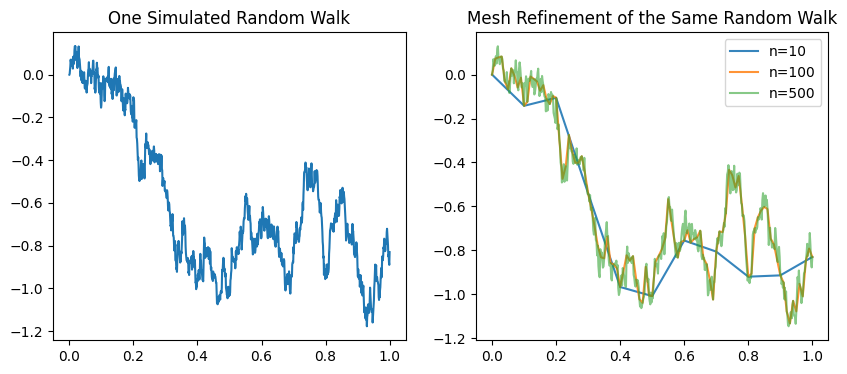

In [2]:
# Parameters #

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #


# Function to simulate a random walk
def simulate_rw(n_sims, n_terms, T):
    dt = T / n_terms
    Z = np.random.normal(0,T,(n_sims,n_terms))
    W = np.insert(np.cumsum(np.sqrt(dt)*Z), 0, 0)
    t = np.linspace(0, T, n_terms+1)
    return t, W

n_fine = 1000  # finest mesh
T = 1.0
t_fine, W_fine = simulate_rw(1,n_fine,T) # Simulate 1 RW with 1000 steps for T=1.0

# Simulate one random walk for reference
ax1.plot(t_fine,W_fine)
ax1.set_title("One Simulated Random Walk")


for n in [10, 100, 500]:
    step = n_fine // n          # how many fine steps per coarse step
    t_coarse = t_fine[::step] # slices t into coarse components. For example, n=10 -> take every 100th step to get 10 total steps.
    W_coarse = W_fine[::step]
    ax2.plot(t_coarse, W_coarse, label=f"n={n}", alpha=0.9-(n/1500))

ax2.set_title("Mesh Refinement of the Same Random Walk")
ax2.legend()
    

    

On the left, we see a continuous stochastic process. It is difficult to determine more about a potential relationship to Brownian motion from a single path, which motivates the next exhibit. <br>

Looking to the graph on the right, we see how as our mesh refines, the stochastic processes converge in distribution to the stochastic process on the left. Notice how the jaggedness of our paths on the right reduces as our mesh refines and our process looks more continuous. The roughness of the simulated random walk with 500 steps is quite similar to the roughness of our process in the graph on the left.

Now let's look at the properties of a collection of these simulated random walks.

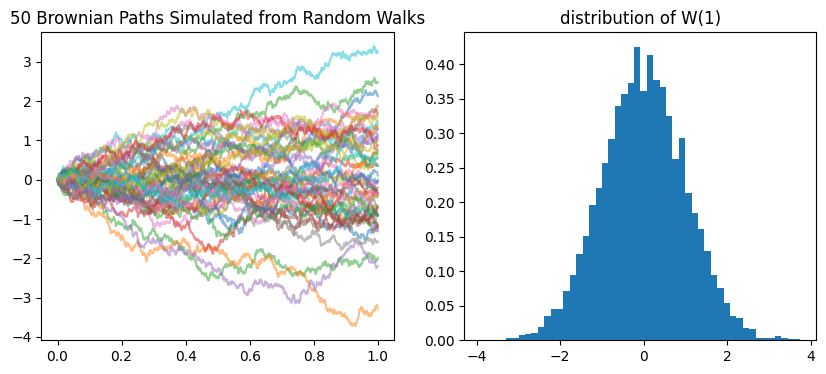

Mean: -0.0   var: 1.008


In [8]:
T = 1.0
n_terms = 1000
dt = T/n_terms

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #

# Simulate many Brownian paths from Random Walks
for _ in range(50):
    t, W = simulate_rw(1,1000,1.0)
    ax1.plot(t,W,alpha=0.5)
ax1.set_title("50 Brownian Paths Simulated from Random Walks")


final_values = []
# Simulate the distribution of 10000 scaled random walks
for _ in range(10000):
    Z=np.random.normal(0,1,n_terms)
    W=np.sum(np.sqrt(dt)*Z)
    final_values.append(W)

# Distribution should be Gaussian (Normal). Check Histogram
ax2.hist(final_values, bins=50, density=True)
ax2.set_title("distribution of W(1)")
plt.show()

print("Mean:", round(np.mean(final_values), 3), "  var:", round(np.var(final_values), 3))

On the histogram to the right, the distribution of the stochastic process at time t=1 can be seen as Gaussian. We also can verify that the distribution of the process has a mean close to 0 and variance close to 1. So we have approximated a stochastic process $W_{1} \sim N(0,1)$ on [0,1]. In other words, we have observed that our stochastic process is consistent with Brownian motion at a fixed time t=1.

Brownian motion satisfies $\operatorname{Var}(W_{t})=t \ \   \forall t$. Above, we showed that our stochastic process was consistent with this requirement for a particular choice of t. We now test whether this holds across time in our simulation.

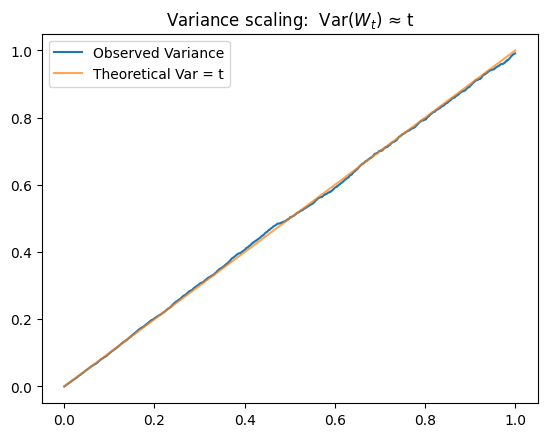

In [9]:
T=1
n_terms = 1000
n_sims = 5000
dt = T/n_terms

# Simulate 50 paths (Note: more efficient simulation code. Documenting that here too)
increments = np.sqrt(dt)*np.random.randn(n_sims,n_terms) # 50xn matrix
W = np.cumsum(increments,axis=1) # Cumulative sum across a row
W = np.hstack([np.zeros((n_sims,1)),W]) # Add initial condition 0 for each path
time = np.linspace(0,1,n_terms + 1) # +1 because of added initial conidition term

observed_var = np.var(W,axis = 0) # taking variance at each time step (column)

plt.plot(time,observed_var,label = "Observed Variance", alpha = 1)
plt.plot(time,time,label="Theoretical Var = t", alpha = 0.7)
plt.legend()
plt.title(f"Variance scaling:  Var($W_t$) ≈ t")
plt.show()

Above, we simulated 5000 random walk processes, demonstrating that our simulated process is consistent with the Brownian variance scaling $\operatorname{Var}(W_{t})=t \ \   \forall t$.

**Covariance Structure**

Recall the second requirement of Brownian motion:
* For $0 \leq s < t$, the increment $W_{t}-W_{s}$ is independent of past increments. <br>

Note that Brownian motion is defined as a Gaussian process, where each finite collection of increments (random variables) is jointly Gaussian. Also note the fact that zero covariance between jointly Gaussian random variables $\iff$ independence of jointly Gaussian random variables.<br>
Thus, to verify the independence of increments, it is sufficient to show that $\operatorname{Cov}(W_{t}-W_{s},\text{past increments}) = 0$<br>

Using this property of independent increments, let's develop a thorough understanding of the covariance structure of Brownian motion. <br>

**Theory** <br>
Consider a Brownian motion W on [0,T] and take $s, t \in [0,T]$ such that s < t. We can evaluate the Brownian motion at both times, $W_t$ and $W_s$. <br>
Rewrite $W_t = W_{s} + (W_{t} - W_{s})$. <br>
It follows that $\operatorname{Cov}(W_s,W_t)=\operatorname{Cov}(W_s,W_{s} + (W_{t} - W_{s}))$.<br>
$\implies \operatorname{Cov}(W_s,W_t)=\operatorname{Var}(W_s)+\operatorname{Cov}(W_s, (W_{t} - W_{s}))$.<br>
Using the property of independent increments, $W_{t}-W_{s}$ is independent of $W_s . \implies \operatorname{Cov}(W_s, (W_{t} - W_{s}))=0$.<br>
Thus, $\operatorname{Cov}(W_s,W_t)=\operatorname{Var}(W_s) = s=\min(s,t)$. <br>


**Intuition** <br>
Consider a Brownian motion W on [0,T] and take $s, t \in [0,T]$ such that s < t. We can evaluate the Brownian motion at both times, $W_t$ and $W_s$. <br>
$W_t$ and $W_s$ share the same path until the time $\min(s,t)$. <br>
Since variance of W scales linearly with time, the covariance between $W_t$ and $W_s$ equals the amount of time that they share.<br>
Thus, $\operatorname{Cov}(W_s,W_t)=\min(s,t)$.<br>

Here we come to a key property of a Brownian motion W: $\operatorname{Cov}(W_s,W_t)=\min(s,t)$.

Now let's look at the covariance structure of our simulated process.

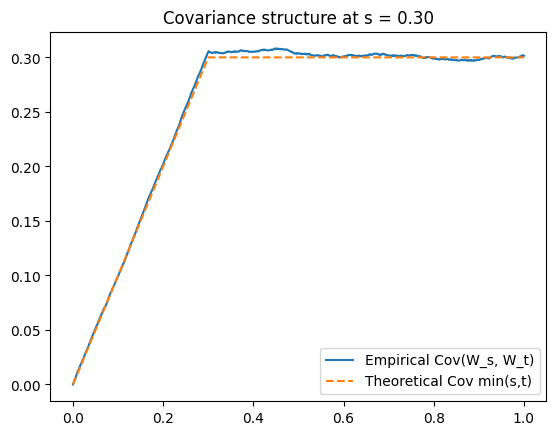

In [10]:
i = 300  # fix s = ith timestep

empirical_covs = [np.mean(W[:, i] * W[:, j]) for j in range(len(time))] # Using fact that Cov(X,Y) = E[XY]-E[X]E[Y] = E[XY] since E[X]=E[Y]=0. 
                                                                        # For each row we get a Cov(W_i,W_j), then we take the sample mean.
theoretical_covs = [min(time[i], t) for t in time] # cov = min(s,t)

plt.plot(time, empirical_covs, label="Empirical Cov(W_s, W_t)")
plt.plot(time, theoretical_covs, '--', label="Theoretical Cov min(s,t)")
plt.legend()
plt.title(f"Covariance structure at s = {time[i]:.2f}")
plt.show()

Since Brownian motion has mean 0, it follows that $\operatorname{Cov}(W_s,W_t) = E[W_tW_s]$. We use this property to estimate the empirical covariance of our simulated random walks by taking the sample mean of $W_tW_s$ across simulations.

We see that $\operatorname{Cov}(W_s,W_t) \approx \min(s,t)$. Thus, the covariance structure of our simulated process is consistent with the covariance structure of Brownian motion, supporting its use as a method of approximation.

**Using series expansions to construct Brownian Motion**

We can go about the same exercises as above for our second method of simulation: series expansion.

Since Brownian smaple paths are continuous functions, we can try to express the paths as a Fourier series. <br>
However, the paths are random functions, which means that the Fourier series coefficients must be random variables. <br>
Since the process which we are trying to expand is Gaussian, our Fourier series coefficients must also be Gaussian

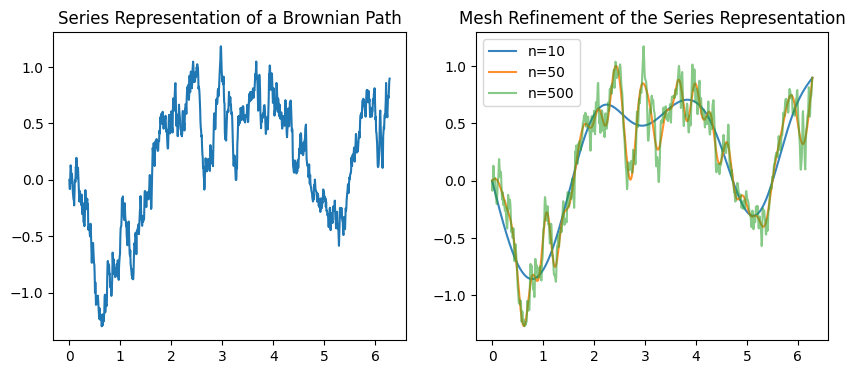

In [11]:
# time
T=2*np.pi
#increments
n_terms = 1000
mesh_size = 1000
dt = T/n_terms


# Plot single path for reference
t = np.linspace(0,T,mesh_size)
Z=np.random.normal(0,1,n_terms + 1)
# Create path and set first term
W = (Z[0] * t) / (np.sqrt(2*np.pi))
for i in range(1, n_terms + 1):
    W += (2/np.sqrt(np.pi))*((Z[i]/i) * np.sin(i * t/2))
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #

ax1.plot(t,W)
ax1.set_title("Series Representation of a Brownian Path")

# Plot paths with refining mesh. Note: we can leave Z as defined above. For series expansion, we are taking first 10, 50, ... terms.
# We do not need to "take every 10th term" with a random walk. Rather, we truncate after 10, 50, 500 terms.
for n in [10, 50, 500]:
    W = (Z[0] * t) / (np.sqrt(2*np.pi))
    for k in range(1, n+1):
        W += (2/np.sqrt(np.pi))*((Z[k]/k) * np.sin(k * t/2))
    ax2.plot(t, W, label=f"n={n}", alpha=0.9-(n/1500))

ax2.set_title("Mesh Refinement of the Series Representation")
ax2.legend()
plt.show()
    

Just as with the simulated random walks, assume the path on the left is a Brownian motion. Looking at the graph on the right, we can see the increase in accuracy as our mesh refines in a much clearer way than with random walks.

Again, we must look at the distributional properties to evaluate the effectiveness of this approximation method.

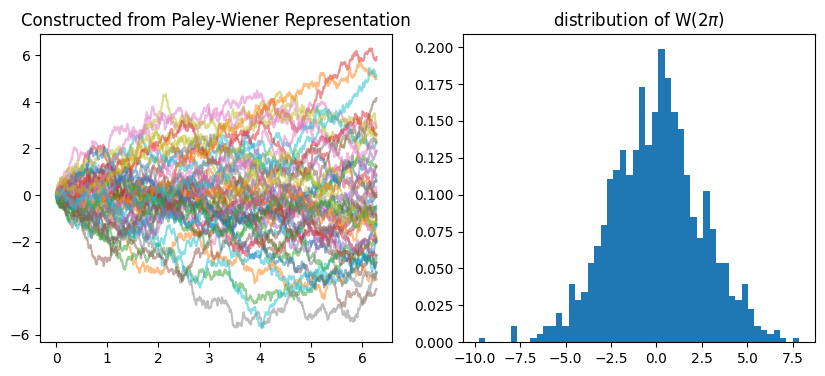

Mean: -0.024   var: 6.287
Variance ≈ 2π ≈ 6.283


In [12]:
# time - changing to 2pi for the natural period of the fourier functions
T=2*np.pi
#increments
n_terms = 1000
mesh_size = 1000
dt = T/mesh_size

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #


t = np.linspace(0,T,mesh_size)

for _ in range(50):
    Z=np.random.normal(0,1,n_terms + 1)
    # Create path and set first term
    Y = (Z[0] * t) / (np.sqrt(2*np.pi))
    for i in range(1, n_terms + 1):
        Y += (2/np.sqrt(np.pi))*((Z[i]/i) * np.sin(i * t/2))
    ax1.plot(t,Y,alpha=0.5)
ax1.set_title("Constructed from Paley-Wiener Representation")



Series_vals = []
# Simulate the distribution of 10000 scaled random walks
for _ in range(1000):
    X=np.random.normal(0,1,n_terms + 1)
    # Create path and set first term
    Y = (X[0] * t) / (np.sqrt(2*np.pi))
    for i in range(1, n_terms + 1):
        Y += (2/np.sqrt(np.pi))*((X[i]/i) * np.sin(i * t/2))
    Series_vals.append(Y[-1])

    
# Distribution should be Gaussian (Normal). Check Histogram
ax2.hist(Series_vals, bins=50, density=True)
ax2.set_title(f"distribution of W(2$\\pi$)")
plt.show()


print("Mean:", round(np.mean(Series_vals), 3), "  var:", round(np.var(Series_vals), 3))
print(f"Variance ≈ 2π ≈ {2*np.pi:.3f}")

We can still see Gaussian distribution on the right, albeit a bit more difficult to spot. Note that the mean of our distribution at t=2$\pi$ is approximately 0, and the variance is approximately 2$\pi$. Since we changed this example to try and approximate Brownian motion on (0,2$\pi$), these are exactly the distributional properties we sought.

Brownian motion satisfies $\operatorname{Var}(W_{t})=t \ \   \forall t$. Above, we showed that our stochastic process was consistent with this requirement for a particular choice of t. Work similar to the simulated random walks can be done here to verify that the variance scaling and covariance structure of this method match the theoretical expectations of Brownian motion.

**Compare our two methods of Brownian motion construction**

It may be helpful to compare the two explored methods of approximation to one another, so as to see how similar they are. Specifically, this may help with the visualization of the Paley-Wiener representation as Gaussian.

Below we simulate 50 paths from each method

Text(0.5, 1.0, 'Simulated from Random Walks')

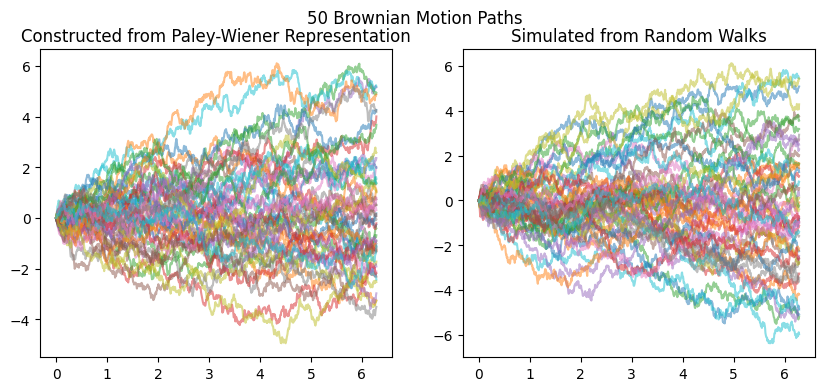

In [13]:
# time - changing to 2pi for the natural period of the fourier functions
T=2*np.pi
#increments
n_terms = 1000
mesh_size = 1000
dt = T/mesh_size

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #
fig.suptitle("50 Brownian Motion Paths")


t = np.linspace(0,T,mesh_size)

for _ in range(50):
    Z=np.random.normal(0,1,n_terms + 1)
    # Create path and set first term
    Y = (Z[0] * t) / (np.sqrt(2*np.pi))
    for i in range(1, n_terms + 1):
        Y += (2/np.sqrt(np.pi))*((Z[i]/i) * np.sin(i * t/2))
    ax1.plot(t,Y,alpha=0.5)
ax1.set_title("Constructed from Paley-Wiener Representation")

# Simulate many Brownian paths from Random Walks
for _ in range(50):
    Z = np.random.normal(0,1,mesh_size-1)
    W = np.insert(np.cumsum(np.sqrt(dt)*Z),0,0)
    ax2.plot(t,W,alpha=0.5)
ax2.set_title("Simulated from Random Walks")


These look similar, but obviously not exact matches. Let's turn to the distributional comparisons

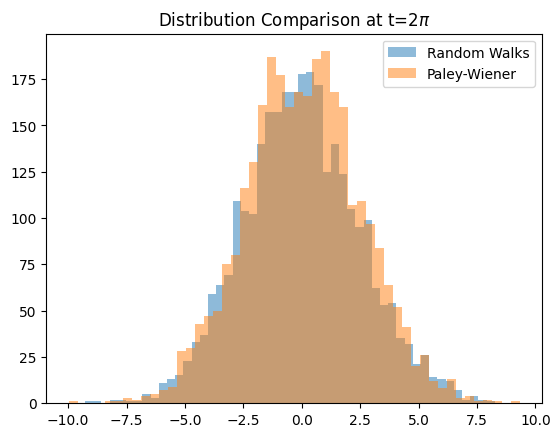

RW mean: -0.002   var: 6.242
Series mean: 0.091   var: 6.16
Both should have mean ≈ 0 and variance ≈ 2π ≈ 6.283


In [14]:
# time - changing to 2pi for the natural period of the fourier functions
T=2*np.pi
#increments
n_terms = 1000
mesh_size = 1000
dt = T/mesh_size

n_sim = 3000
RW_vals = []
Series_vals = []

t = np.linspace(0,T,mesh_size)

for _ in range(n_sim):
    # Simulations of random walks.
    Z = np.random.normal(0,1,mesh_size - 1)
    W_full = np.cumsum(np.sqrt(dt)*Z)
    RW_vals.append(W_full[-1])  # W_T

   # Simulations of Paley-Weiner (Fourier approximation of Brownian motion)
    X=np.random.normal(0,1,n_terms + 1)
    # Create path and set first term
    Y = (X[0] * t) / (np.sqrt(2*np.pi))
    for i in range(1, n_terms + 1):
        Y += (2/np.sqrt(np.pi))*((X[i]/i) * np.sin(i * t/2))
    Series_vals.append(Y[-1])


#Compare our two vectors. After simulations, how are the endpoints of our two motions distributed?
plt.hist(RW_vals, bins=50, alpha=0.5, label=r'Random Walks')
plt.hist(Series_vals, bins=50, alpha=0.5, label=r'Paley-Wiener')
plt.legend()
plt.title("Distribution Comparison at t=$2\\pi$")
plt.show()

print("RW mean:", round(np.mean(RW_vals), 3), "  var:", round(np.var(RW_vals), 3))
print("Series mean:", round(np.mean(Series_vals), 3), "  var:", round(np.var(Series_vals), 3))
print(f"Both should have mean ≈ 0 and variance ≈ 2π ≈ {2*np.pi:.3f}")

Here, we can see how the distribution of the endpoints of paths from Paley-Wiener approximation closely matches the distribution from the limit of random walks. Both are easy to visualize as Gaussian. So visually, we can see how a series expansion like Paley-Wiener can effectively approximate Brownian motion in the same way as the limit of random walks. <br>

Additionally, we see the similarities of means and variances between both methods and the expected mean and variance of Brownian motion. 

**Summary**

In this notebook, we discussed the necessity of approximating Brownian motion for simulation and proposed two methods of simulation: a random walk approximation and a series expansion approach. We verified that these methods of simulation reproduce desired distributional properties including Gaussian marginals, variance scaling and covariance structure. We ended with a short comparison of these methods. <br>

**Further Explorations**

Continued work in this notebook could build upon the following areas:
* Inclusion of other series expansions, such as the Lévy representation
* Further comparison of simulation methods and practical trade-offs (computational cost, convergence, ease of implementation, numerical stability)